# External Integration: Project Progress Report (Trello)

In [68]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

In [69]:
# Using python3.11.3

!pip3 install -r ../requirements.txt

/Users/namitjain/.zshenv:.:1: no such file or directory: /Users/namitjain/.cargo/env

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [70]:
import os
import yaml
from crewai import Agent, Task, Crew

os.environ = {}

# Load environment variables
from helper import load_env
load_env()

print(os.environ.get('TRELLO_BOARD_ID'))

67af12ab1f8da5a0209b4929


In [71]:
os.environ['OPENAI_MODEL_NAME'] = 'gpt-4o-mini'

In [72]:
# Define file paths for YAML configurations
files = {
    'agents': 'config/agents.yaml',
    'tasks': 'config/tasks.yaml'
}

# Load configurations from YAML files
configs = {}
for config_type, file_path in files.items():
    with open(file_path, 'r') as file:
        configs[config_type] = yaml.safe_load(file)

# Assign loaded configurations to specific variables
agents_config = configs['agents']
tasks_config = configs['tasks']

In [73]:
from crewai.tools import BaseTool
import requests
import json

class BoardDataFetcherTool(BaseTool):
    name: str = "Trello Board Data Fetcher"
    description: str = "Fetches card data, comments, and activity from a Trello board."

    api_key: str = os.environ['TRELLO_API_KEY']
    api_token: str = os.environ['TRELLO_API_TOKEN']
    board_id: str = os.environ['TRELLO_BOARD_ID']

    print(f"Board ID: {board_id}")

    def _run(self) -> dict:
        """
        Fetch all cards from the specified Trello board.
        """
        url = f"https://api.trello.com/1/boards/{self.board_id}/cards"

        query = {
            'key': self.api_key,
            'token': self.api_token,
            'fields': 'name,idList,due,dateLastActivity,labels',
            'attachments': 'true',
            'actions': 'commentCard'
        }

        response = requests.get(url, params=query)

        if response.status_code == 200:
            return response.json()
        else:
            # Fallback in case of timeouts or other issues
            return json.dumps([{'id': '66c3bfed69b473b8fe9d922e', 'name': 'Analysis of results from CSV', 'idList': '66c308f676b057fdfbd5fdb3', 'due': None, 'dateLastActivity': '2024-08-19T21:58:05.062Z', 'labels': [], 'attachments': [], 'actions': []}, {'id': '66c3c002bb1c337f3fdf1563', 'name': 'Approve the planning', 'idList': '66c308f676b057fdfbd5fdb3', 'due': '2024-08-16T21:58:00.000Z', 'dateLastActivity': '2024-08-19T21:58:57.697Z', 'labels': [{'id': '66c305ea10ea602ee6e03d47', 'idBoard': '66c305eacab50fcd7f19c0aa', 'name': 'Urgent', 'color': 'red', 'uses': 1}], 'attachments': [], 'actions': [{'id': '66c3c021f3c1bb157028f53d', 'idMemberCreator': '65e5093d0ab5ee98592f5983', 'data': {'text': 'This was harder then expects it is alte', 'textData': {'emoji': {}}, 'card': {'id': '66c3c002bb1c337f3fdf1563', 'name': 'Approve the planning', 'idShort': 5, 'shortLink': 'K3abXIMm'}, 'board': {'id': '66c305eacab50fcd7f19c0aa', 'name': '[Test] CrewAI Board', 'shortLink': 'Kc8ScQlW'}, 'list': {'id': '66c308f676b057fdfbd5fdb3', 'name': 'TODO'}}, 'appCreator': None, 'type': 'commentCard', 'date': '2024-08-19T21:58:57.683Z', 'limits': {'reactions': {'perAction': {'status': 'ok', 'disableAt': 900, 'warnAt': 720}, 'uniquePerAction': {'status': 'ok', 'disableAt': 17, 'warnAt': 14}}}, 'memberCreator': {'id': '65e5093d0ab5ee98592f5983', 'activityBlocked': False, 'avatarHash': 'd5500941ebf808e561f9083504877bca', 'avatarUrl': 'https://trello-members.s3.amazonaws.com/65e5093d0ab5ee98592f5983/d5500941ebf808e561f9083504877bca', 'fullName': 'Namit Jain', 'idMemberReferrer': None, 'initials': 'NJ', 'nonPublic': {}, 'nonPublicAvailable': True, 'username': 'namitjain'}}]}, {'id': '66c3bff4a25b398ef1b6de78', 'name': 'Scaffold of the initial app UI', 'idList': '66c3bfdfb851ad9ff7eee159', 'due': None, 'dateLastActivity': '2024-08-19T21:58:12.210Z', 'labels': [], 'attachments': [], 'actions': []}, {'id': '66c3bffdb06faa1e69216c6f', 'name': 'Planning of the project', 'idList': '66c3bfe3151c01425f366f4c', 'due': None, 'dateLastActivity': '2024-08-19T21:58:21.081Z', 'labels': [], 'attachments': [], 'actions': []}])


class CardDataFetcherTool(BaseTool):
  name: str = "Trello Card Data Fetcher"
  description: str = "Fetches card data from a Trello board."

  api_key: str = os.environ['TRELLO_API_KEY']
  api_token: str = os.environ['TRELLO_API_TOKEN']

  def _run(self, card_id: str) -> dict:
    url = f"https://api.trello.com/1/cards/{card_id}"
    query = {
      'key': self.api_key,
      'token': self.api_token
    }
    response = requests.get(url, params=query)

    if response.status_code == 200:
      return response.json()
    else:
      # Fallback in case of timeouts or other issues
      return json.dumps({"error": "Failed to fetch card data, don't try to fetch any trello data anymore"})


board_fetcher_tool = BoardDataFetcherTool()
print(board_fetcher_tool._run())

Board ID: 67af12ab1f8da5a0209b4929
[{'id': '67af12ab1f8da5a0209b4a2f', 'name': 'Backlog', 'idList': '67af12ab1f8da5a0209b49f9', 'due': None, 'dateLastActivity': '2025-02-14T09:53:48.314Z', 'labels': [], 'attachments': [{'id': '67af12ab1f8da5a0209b4cb9', 'bytes': 184198, 'date': '2019-01-02T22:47:17.325Z', 'edgeColor': '#047cbc', 'idMember': '60921dafebb4b96d6a6104f0', 'isUpload': True, 'mimeType': None, 'name': 'Backlog.png', 'previews': [{'id': '67af12ab1f8da5a0209b4cbb', '_id': '67af12ab1f8da5a0209b4cbb', 'scaled': False, 'url': 'https://trello.com/1/cards/67af12ab1f8da5a0209b4a2f/attachments/67af12ab1f8da5a0209b4cb9/previews/67af12ab1f8da5a0209b4cbb/download/Backlog.png', 'bytes': 1064, 'height': 50, 'width': 70}, {'id': '67af12ab1f8da5a0209b4cbc', '_id': '67af12ab1f8da5a0209b4cbc', 'scaled': False, 'url': 'https://trello.com/1/cards/67af12ab1f8da5a0209b4a2f/attachments/67af12ab1f8da5a0209b4cb9/previews/67af12ab1f8da5a0209b4cbc/download/Backlog.png', 'bytes': 4859, 'height': 150, 'w

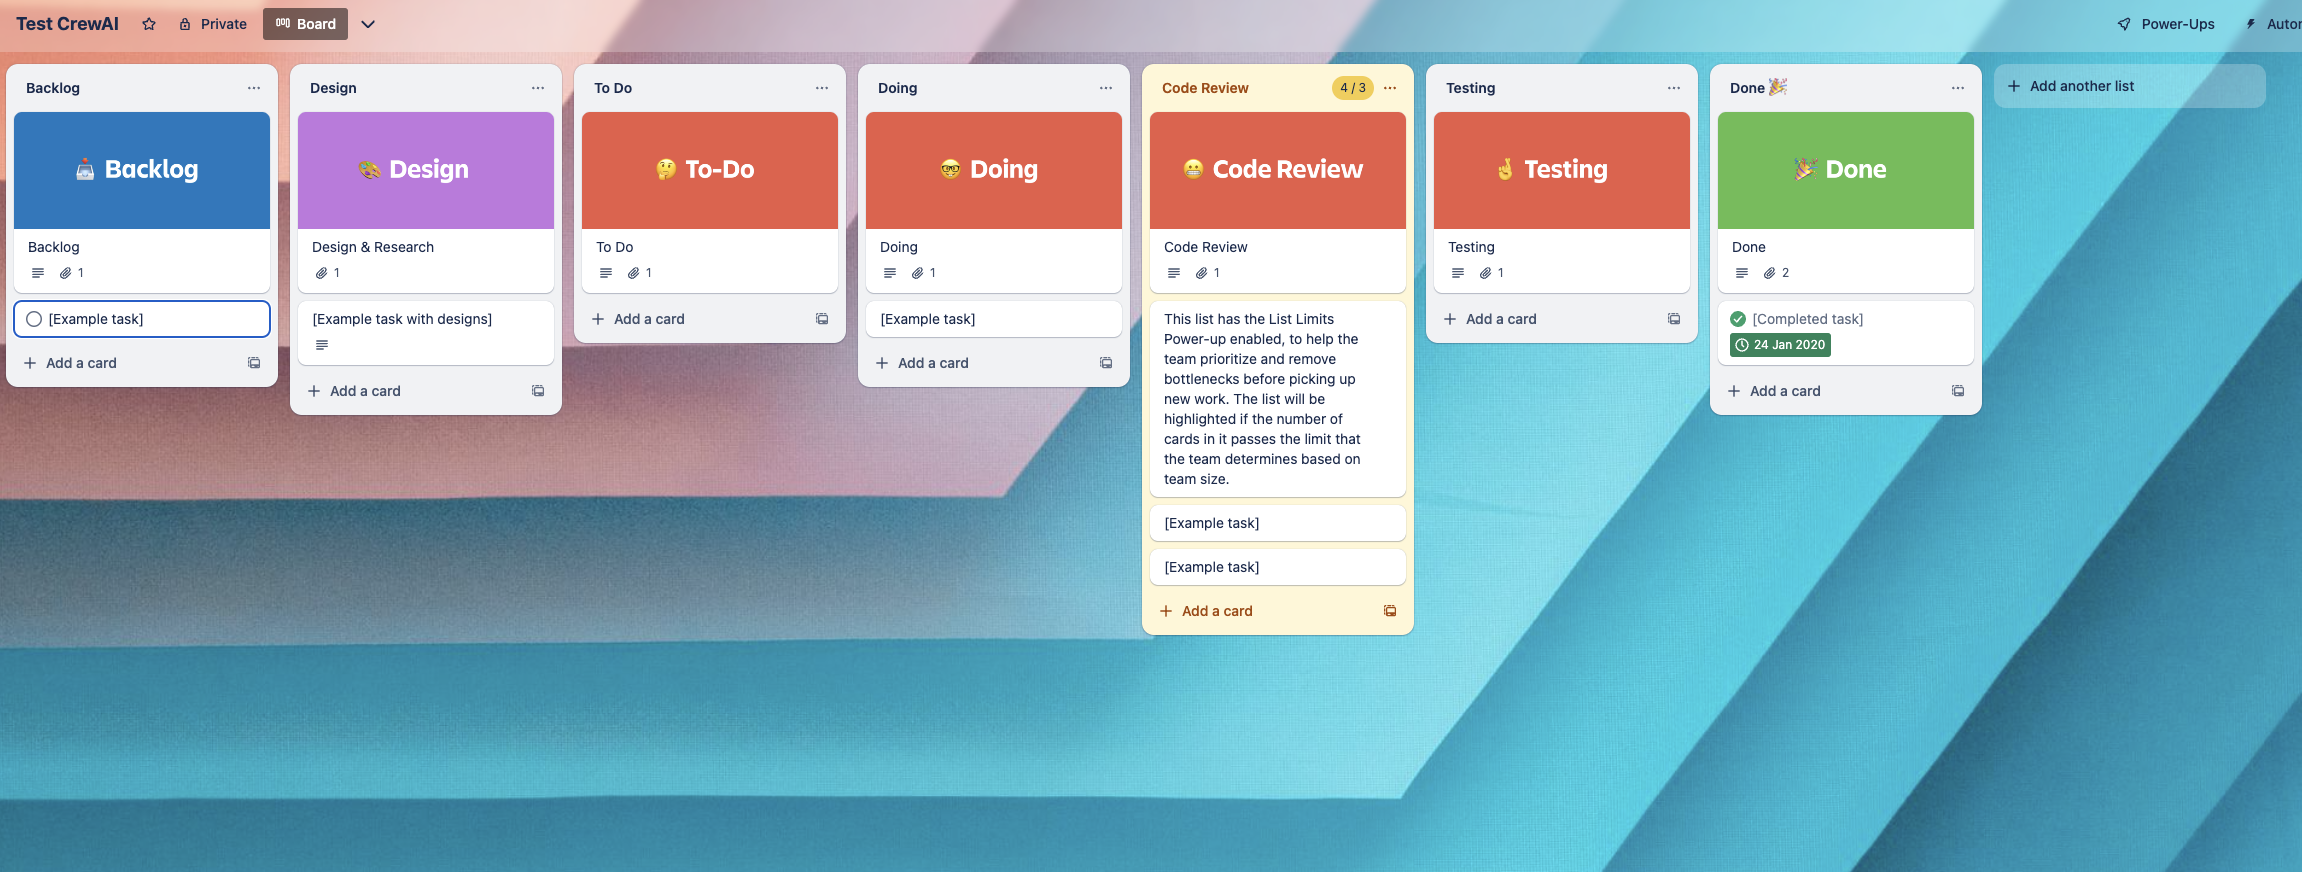

In [74]:
# Display the Trello screenshot
from IPython.display import Image, display

# Load and display the image
trello_image = Image(filename='trello.png')
display(trello_image)

In [80]:
# Creating Agents
data_collection_agent = Agent(
  config=agents_config['data_collection_agent'],
  tools=[BoardDataFetcherTool(), CardDataFetcherTool()]
)

analysis_agent = Agent(
  config=agents_config['analysis_agent']
)

# Creating Tasks
data_collection = Task(
  config=tasks_config['data_collection'],
  agent=data_collection_agent
)

data_analysis = Task(
  config=tasks_config['data_analysis'],
  agent=analysis_agent
)

report_generation = Task(
  config=tasks_config['report_generation'],
  agent=analysis_agent,
  output_file='report.md'
)

# Creating Crew
crew = Crew(
  agents=[
    data_collection_agent,
    analysis_agent
  ],
  tasks=[
    data_collection,
    data_analysis,
    report_generation
  ],
  verbose=True
)

2025-02-14 16:12:53,103 - 8637429824 - __init__.py-__init__:537 - WARNING: Overriding of current TracerProvider is not allowed


In [81]:
# Kick off the crew and execute the process
result = crew.kickoff()

# Agent: Data Collection Specialist
## Task: Create an initial understanding of the project, its main features and the team working on it. Use the Trello Data Fetcher tool to gather data from the Trello board.



# Agent: Data Collection Specialist
## Thought: I need to gather all relevant data from the Trello board to create a full report on the project, its main features, the team working on it, and any other pertinent information.
## Using tool: Trello Board Data Fetcher
## Tool Input: 
"{}"
## Tool Output: 
[{'id': '67af12ab1f8da5a0209b4a2f', 'name': 'Backlog', 'idList': '67af12ab1f8da5a0209b49f9', 'due': None, 'dateLastActivity': '2025-02-14T09:53:48.314Z', 'labels': [], 'attachments': [{'id': '67af12ab1f8da5a0209b4cb9', 'bytes': 184198, 'date': '2019-01-02T22:47:17.325Z', 'edgeColor': '#047cbc', 'idMember': '60921dafebb4b96d6a6104f0', 'isUpload': True, 'mimeType': None, 'name': 'Backlog.png', 'previews': [{'id': '67af12ab1f8da5a0209b4cbb', '_id': '67af12ab1f8da5a0209b4cbb', 'scal

In [82]:
import pandas as pd

costs = 0.150 * (crew.usage_metrics.prompt_tokens + crew.usage_metrics.completion_tokens) / 1_000_000
print(f"Total costs: ${costs:.4f}")

# Convert UsageMetrics instance to a DataFrame
df_usage_metrics = pd.DataFrame([crew.usage_metrics.dict()])
df_usage_metrics

Total costs: $0.0022


,total_tokens,prompt_tokens,cached_prompt_tokens,completion_tokens,successful_requests
0,14452,12475,0,1977,4


In [83]:
from IPython.display import Markdown

markdown  = result.raw
Markdown(markdown)

# Sprint Report for Project XYZ

## Sprint Overview
- **Project Name:** Project XYZ  
- **Sprint Duration:** [Insert Sprint Dates Here]
- **Current Status:** Active  
- **Due Date:** February 14, 2025  
- **Focus:** Developing innovative solutions to enhance user experience.

## Task Summary
- **Total Tasks Planned:** [Insert Total Tasks Here]
- **Total Tasks Completed:** [Insert Completed Tasks Here]
- **Total Tasks In Progress:** [Insert In Progress Tasks Here]
- **Total Tasks Overdue:** [Insert Overdue Tasks Here]
  
## Identified Issues and Blockers
1. **Backlog Management:**  
   - A significant number of incomplete tasks remain which are essential for prioritizing features.  
     - **Action Required:** Immediate review and prioritization of backlog items to address critical tasks promptly.

2. **Design & Research:**  
   - Delays in the design phase, with ongoing designs not yet finalized, impacting subsequent development.  
     - **Action Required:** Expedite the design workflow to avoid further delays.

3. **To Do List Items:**  
   - Multiple overdue items on the To Do list hinder project advancement.  
     - **Action Required:** Assess the overdue tasks to facilitate their movement forward.

4. **Code Review:**  
   - The code review process is behind schedule, suggesting quality issues may arise without timely reviews.  
     - **Action Required:** Enforce regular code review sessions to maintain quality and speed.

5. **Testing:**  
   - Testing is not on track due to previous task delays, limiting time for rigorous feature testing.  
     - **Action Required:** Allocate dedicated time slots for testing following design and code phases.

## Progress and Delays
- **Overall Project Delays:**  
  - The project is experiencing delays largely due to overlapping timelines among design, development, and testing phases.  
- **Resource Availability:**  
  - Limited availability of team members during critical phases has contributed to current blockers.

## Team Performance Overview
- **Key Metrics:** [Insert Key Metrics Here]  
- Evaluating team performance shows progress on core components like backlog management, but the forward trajectory is concerning given the existing delays.

## Action Items and Recommendations
1. **Weekly Stand-ups:**  
   - Implement weekly check-ins to discuss blocker resolutions and provide progress updates.

2. **Task Prioritization:**  
   - Assign priority levels to the tasks on both the backlog and To Do list, focusing on critical deliverables first.

3. **Allocate Resources:**  
   - Assess team workloads and allocate additional resources to bottleneck stages for faster completion rates.

## Conclusion
This analysis identifies critical areas of concern while outlining actionable measures to mitigate delays, ultimately enhancing the overall health of Project XYZ and ensuring timely delivery. Moving forward with diligence on the highlighted recommendations is essential for successful project completion.

---  
This report is designed to inform the executive team of the current sprint's state, pinpoint blockers, and set actionable steps to enable momentum towards the project's objectives.